**BIBLIOTECAS**

In [17]:
# IMPORTAÇÃO DE BIBLIOTECAS\+
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    chi2
)

from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from joblib import Memory

**CARREGAMENTO DOS DADOS**

In [18]:

df_train = pd.read_parquet("datasense_full_train_1sec.parquet")
df_test  = pd.read_parquet("datasense_full_test_1sec.parquet")

print("Train:", df_train.shape)
print("Test :", df_test.shape)

Train: (170393, 115)
Test : (56798, 115)


**DEFINIÇÃO DO TARGET**

In [19]:

# TARGET
# ==========================================================
# label1 = variável original do dataset
# "attack" = comportamento malicioso (classe positiva = 1)
# qualquer outro valor = normal (classe negativa = 0)

# CONVERSÃO PARA PROBLEMA BINÁRIO
y_train = (df_train["label1"] == "attack").astype(int)
y_test  = (df_test["label1"] == "attack").astype(int)


# VERIFICAÇÃO DA DISTRIBUIÇÃO
print("✔ Distribuição no treino:")
print(y_train.value_counts())

print("\n✔ Distribuição no teste:")
print(y_test.value_counts())

✔ Distribuição no treino:
label1
0    102600
1     67793
Name: count, dtype: int64

✔ Distribuição no teste:
label1
0    34200
1    22598
Name: count, dtype: int64


In [20]:
# TARGET (label1 → binário)

target_col = "label1"

y_train = (df_train[target_col] == "attack").astype(int)
y_test  = (df_test[target_col] == "attack").astype(int)

**LIMPEZA E FEATURES**

In [21]:
cols_to_drop = ["label1", "label2", "label3", "label4", "label_extended"]

X_train = df_train.drop(columns=cols_to_drop)
X_test  = df_test.drop(columns=cols_to_drop)

# One-hot encoding
X_train = pd.get_dummies(X_train)
X_test  = pd.get_dummies(X_test)

# alinhar colunas
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("Features:", X_train.shape)

Features: (170393, 149)


**ANÁLISE DAS CLASSES**

✔ Distribuição no TREINO:
label1
0    102600
1     67793
Name: count, dtype: int64

✔ Distribuição no TESTE:
label1
0    34200
1    22598
Name: count, dtype: int64


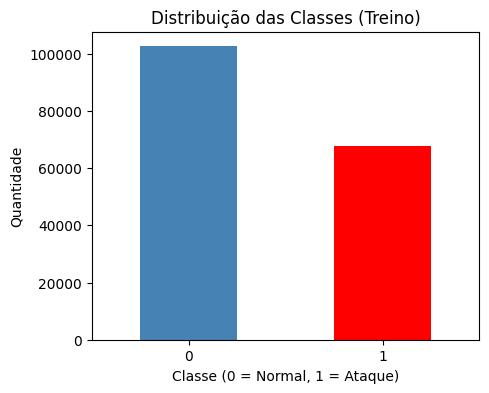


Interpretação:
- Classe 0 = tráfego normal
- Classe 1 = ataques (anomalias IIoT)
- Dataset possivelmente desbalanceado → justificar uso de class_weight='balanced'


In [22]:
# ANÁLISE DE CLASSES — DETECÇÃO DE ATAQUES IIoT

# CONTAGEM DAS CLASSES
train_counts = y_train.value_counts()
test_counts  = y_test.value_counts()

print("✔ Distribuição no TREINO:")
print(train_counts)

print("\n✔ Distribuição no TESTE:")
print(test_counts)

# VISUALIZAÇÃO
plt.figure(figsize=(5,4))

train_counts.plot(kind='bar', color=['steelblue', 'red'])

plt.title("Distribuição das Classes (Treino)")
plt.xlabel("Classe (0 = Normal, 1 = Ataque)")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)

plt.show()


# INTERPRETAÇÃO (IMPORTANTE PARA ARTIGO)
print("\nInterpretação:")
print("- Classe 0 = tráfego normal")
print("- Classe 1 = ataques (anomalias IIoT)")
print("- Dataset possivelmente desbalanceado → justificar uso de class_weight='balanced'")

**REMOÇÃO DE COLINEARIDADE**

In [23]:
# SELEÇÃO DE FEATURES (LIGHTWEIGHT - SEM VIF)

from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

# Remove features constantes
vt = VarianceThreshold(threshold=0.0)
X_train_vt = vt.fit_transform(X_train)
X_test_vt = vt.transform(X_test)

# Normalização (necessário para chi2)
scaler_fs = MinMaxScaler()
X_train_fs = scaler_fs.fit_transform(X_train_vt)
X_test_fs = scaler_fs.transform(X_test_vt)

#Seleção estatística (Top K features)
selector = SelectKBest(score_func=chi2, k=120)

X_train_sel = selector.fit_transform(X_train_fs, y_train)
X_test_sel = selector.transform(X_test_fs)

print("✔ Features removidas:", X_train.shape[1] - X_train_sel.shape[1])
print("✔ Features finais:", X_train_sel.shape[1])

✔ Features removidas: 29
✔ Features finais: 120


**MODELO**

In [ ]:
# CACHE DO PIPELINE
# Evita recomputar transformações pesadas (feature selection etc.)
# durante cross-validation ou reexecuções do notebook
memory = Memory(location="./cache_pipeline", verbose=0)


# PIPELINE FINAL — DETECÇÃO DE ATAQUES IIoT

pipeline = Pipeline([

    # REMOÇÃO DE FEATURES CONSTANTES
    # Remove colunas sem variação (ex: tudo 0 ou constante)
    # Reduz ruído e melhora estabilidade do modelo
    ('var_filter', VarianceThreshold(threshold=0.0)),

    # NORMALIZAÇÃO (PRÉ-SELEÇÃO)

    # Necessária para o chi² funcionar corretamente
    # Coloca dados em escala [0, 1]
    ('scaler_fs', MinMaxScaler()),

    # SELEÇÃO DE FEATURES (CHI²)
    # Seleciona as 120 features mais relevantes estatisticamente
    # Reduz dimensionalidade e acelera treino
    ('feature_select', SelectKBest(
        score_func=chi2,
        k=120
    )),


    # PADRONIZAÇÃO FINAL (MODELO LINEAR)
    # Ajusta distribuição para média 0 e variância 1
    # Essencial para regressão logística estável
    ('scaler', StandardScaler()),


    # MODELO FINAL — REGRESSÃO LOGÍSTICA
    # Modelo linear interpretável para detecção de ataques IIoT
    ('model', LogisticRegression(

        solver='saga',          # eficiente para grandes datasets

        #SEM WARNING + L1 CORRETO
        penalty='elasticnet',
        l1_ratio=1.0,           # L1 puro → melhor detecção de ataques

        C=1.0,                  # força da regularização
        max_iter=2000,         # convergência estável
        tol=1e-3,              # acelera treino sem perder estabilidade

        class_weight='balanced', # corrige desbalanceamento (ataques raros)
        random_state=42         # reprodutibilidade científica
    ))

], memory=memory)

**TREINAMENTO**

In [25]:
pipeline.fit(X_train, y_train)
print("Modelo treinado com sucesso!")

c:\Users\bruno.lima\Documents\Projeto IIOT\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Modelo treinado com sucesso!


**VALIDAÇÃO CRUZADA**

In [26]:
# CROSS-VALIDATION OTIMIZADA

cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1   # 🚀 acelera o treino em múltiplos cores
)

print("F1 Scores:", scores)
print("F1 Médio:", scores.mean())

F1 Scores: [0.86186034 0.86418984]
F1 Médio: 0.863025088989201


**PREDIÇÃO - DETECÇÃO DE ATAQUES**

Total de amostras no teste: 56798
Ataques reais no teste: 22598
Ataques detectados pelo modelo: 18230


,network_fragmentation-score,network_fragmented-packets,network_header-length_avg,network_header-length_max,network_header-length_min,network_header-length_std_deviation,network_interval-packets,network_ip-flags_avg,network_ip-flags_max,network_ip-flags_min,network_ip-flags_std_deviation,network_ip-length_avg,network_ip-length_max,network_ip-length_min,network_ip-length_std_deviation,network_ips_all_count,network_ips_dst_count,network_ips_src_count,network_macs_all_count,network_macs_dst_count,network_macs_src_count,network_mss_avg,network_mss_max,network_mss_min,network_mss_std_deviation,network_packet-size_avg,network_packet-size_max,network_packet-size_min,network_packet-size_std_deviation,network_packets_all_count,network_packets_dst_count,network_packets_src_count,network_payload-length_avg,network_payload-length_max,network_payload-length_min,network_payload-length_std_deviation,network_ports_all_count,network_ports_dst_count,network_ports_src_count,network_protocols_all_count,network_protocols_dst_count,network_protocols_src_count,network_tcp-flags-ack_count,network_tcp-flags-fin_count,network_tcp-flags-psh_count,network_tcp-flags-rst_count,network_tcp-flags-syn_count,network_tcp-flags-urg_count,network_tcp-flags_avg,network_tcp-flags_max,network_tcp-flags_min,network_tcp-flags_std_deviation,network_time-delta_avg,network_time-delta_max,network_time-delta_min,network_time-delta_std_deviation,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min,network_window-size_std_deviation,network_protocols_src_has_udp,network_protocols_src_has_ssh,network_protocols_src_has_tcp,network_protocols_src_has_http,network_protocols_src_has_data,network_protocols_src_has_xlm,network_protocols_src_has_mqtt,network_protocols_src_has_lbtrm,network_protocols_src_has_dns,network_protocols_src_has_telnet,network_protocols_src_has_arp,network_protocols_src_has_icmp,network_protocols_dst_has_udp,network_protocols_dst_has_ssh,network_protocols_dst_has_tcp,network_protocols_dst_has_http,network_protocols_dst_has_data,network_protocols_dst_has_xlm,network_protocols_dst_has_mqtt,network_protocols_dst_has_lbtrm,network_protocols_dst_has_dns,network_protocols_dst_has_telnet,network_protocols_dst_has_arp,network_protocols_dst_has_icmp,network_ports_src_has_9595,network_ports_src_has_443,network_ports_src_has_1883,network_ports_src_has_22,network_ports_src_has_554,network_ports_src_has_80,network_ports_src_has_8000,network_ports_src_has_23,network_ports_src_has_6668,network_ports_src_has_557,network_ports_dst_has_9595,network_ports_dst_has_443,network_ports_dst_has_1883,network_ports_dst_has_22,network_ports_dst_has_554,network_ports_dst_has_80,network_ports_dst_has_8000,network_ports_dst_has_23,network_ports_dst_has_6668,network_ports_dst_has_557,device_name_accelerometer-sensor,device_name_ap,device_name_blurams-camera,device_name_dekco-camera,device_name_edge1,device_name_flame-sensor,device_name_gas-sensor,device_name_geeni-camera,device_name_light-sensor,device_name_motion-sensor,device_name_mqtt-broker,device_name_myq-camera,device_name_plug-all-cameras,device_name_plug-all-rpb,device_name_plug-all-sensors,device_name_plug-cameras-dekco-blurams,device_name_plug-cameras-geeni,device_name_plug-cameras-yi,device_name_plug-edge1,device_name_plug-flame,device_name_plug-motion,device_name_plug-mqtt,device_name_plug-proximity,device_name_plug-rfid,device_name_plug-vibration,device_name_proximity-collision-sensor,device_name_rfid-sensor,device_name_router,device_name_soil-sensor,device_name_sound-sensor,device_name_steam-sensor,device_name_switch,device_name_ultrasonic-sensor,device_name_vibration-sensor,device_name_water-sensor,device_name_weather-sensor,device_name_wisenet-camera,device_name_yi-camera,device_type_control,device_type_infra,device_type_iot,Real (y_test),Predito (y_pred),Probabilidade_Ataque
0,0.000000,0,0.000000,0.000000,0.000000,0.000000,294.500000

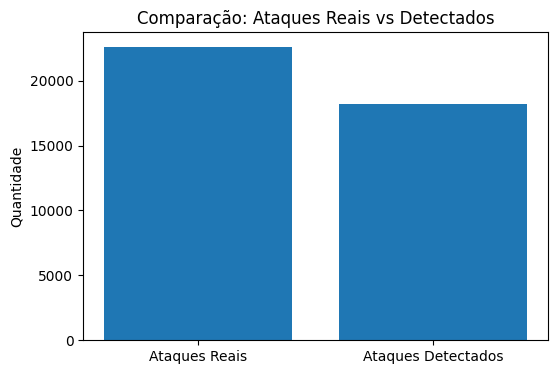


EXEMPLOS DE ATAQUES DETECTADOS (MAIOR PROBABILIDADE):


,network_fragmentation-score,network_fragmented-packets,network_header-length_avg,network_header-length_max,network_header-length_min,network_header-length_std_deviation,network_interval-packets,network_ip-flags_avg,network_ip-flags_max,network_ip-flags_min,...,device_name_water-sensor,device_name_weather-sensor,device_name_wisenet-camera,device_name_yi-camera,device_type_control,device_type_infra,device_type_iot,Real (y_test),Predito (y_pred),Probabilidade_Ataque
56728,0.0,0,20.0,20.0,20.0,0.0,0.018900,1.000038,2.0,0.0,...,False,False,False,False,True,False,False,1,1,1.0
56724,0.0,0,20.0,20.0,20.0,0.0,0.321440,1.001929,2.0,0.0,...,False,False,False,False,False,True,False,1,1,1.0
56712,0.0,0,20.0,20.0,20.0,0.0,0.009851,0.000079,2.0,0.0,...,False,False,False,False,False,True,False,1,1,1.0
122,0.0,0,20.0,20.0,20.0,0.0,0.222800,1.001983,2.0,0.0,...,False,False,False,False,True,False,False,1,1,1.0
25263,0.0,0,20.0,20.0,20.0,0.0,0.230120,0.995658,2.0,0.0,...,False,False,True,False,False,False,True,1,1,1.0
111,0.0,0,20.0,20.0,20.0,0.0,0.208146,1.000500,2.0,0.0,...,False,False,False,False,False,False,True,1,1,1.0
16814,0.0,0,20.0,20.0,20.0,0.0,0.009401,0.000414,2.0,0.0,...,False,False,True,False,False,False,True,1,1,1.0
35576,0.0,0,20.0,20.0,20.0,0.0,0.207068,1.003984,2.0,0.0,...,False,False,True,False,False,False,True,1,1,1.0
35566,0.0,0,20.0,20.0,20.0,0.0,0.009226,0.000000,0.0,0.0,...,True,False,False,False,False,False,True,1,1,1.0
35558,0.0,0,20.0,20.0,20.0,0.0,0.626256,1.002513,2.0,0.0,...,False,False,False,True,False,False,True,1,1,1.0


In [27]:
# PREDIÇÃO + DETECÇÃO DE ATAQUES

import matplotlib.pyplot as plt
from sklearn.utils.validation import check_is_fitted

# VERIFICA SE O PIPELINE FOI TREINADO
check_is_fitted(pipeline)

# PREDIÇÃO

y_pred = pipeline.predict(X_test)

# probabilidade da classe positiva (ataque = 1)
positive_class = 1
y_prob = pipeline.predict_proba(X_test)[:, positive_class]

# DATAFRAME DE RESULTADOS

df_result = X_test.copy()
df_result["Real (y_test)"] = y_test.values
df_result["Predito (y_pred)"] = y_pred
df_result["Probabilidade_Ataque"] = y_prob

# FILTRO DE ATAQUES DETECTADOS

ataques_detectados = df_result[df_result["Predito (y_pred)"] == 1]

print(f"Total de amostras no teste: {len(df_result)}")
print(f"Ataques reais no teste: {df_result['Real (y_test)'].sum()}")
print(f"Ataques detectados pelo modelo: {len(ataques_detectados)}")

# TABELA FORMATADA

def highlight_attacks(row):
    return [
        'background-color: #ffcccc'
        if row["Predito (y_pred)"] == 1 else ''
        for _ in row
    ]

styled_table = df_result.head(20).style.apply(highlight_attacks, axis=1)

display(styled_table)

# GRÁFICO: REAIS vs DETECTADOS

plt.figure(figsize=(6,4))

labels = ['Ataques Reais', 'Ataques Detectados']
values = [
    df_result["Real (y_test)"].sum(),
    len(ataques_detectados)
]

plt.bar(labels, values)
plt.title("Comparação: Ataques Reais vs Detectados")
plt.ylabel("Quantidade")
plt.show()

# EXEMPLOS DE ATAQUES DETECTADOS

print("\nEXEMPLOS DE ATAQUES DETECTADOS (MAIOR PROBABILIDADE):")

display(
    ataques_detectados.sort_values(
        "Probabilidade_Ataque",
        ascending=False
    ).head(10)
)

**MÉTRICAS**

In [28]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.9030599669002429

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92     34200
           1       0.97      0.78      0.87     22598

    accuracy                           0.90     56798
   macro avg       0.92      0.88      0.89     56798
weighted avg       0.91      0.90      0.90     56798

ROC-AUC: 0.914994757725804


**MATRIZ DE CONFUSÃO**

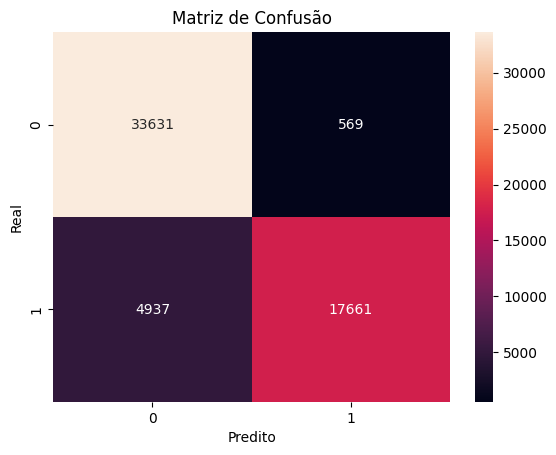

In [29]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

**CURVA ROC**

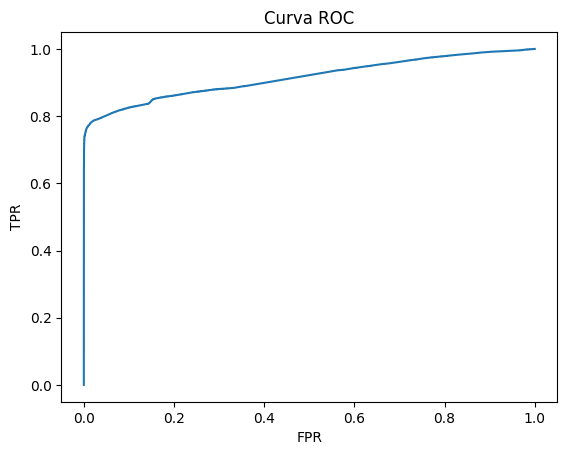

In [30]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.title("Curva ROC")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

**INTERPRETABILIDADE DO MODELO - FEATURE IMPORTANCE**

In [31]:
# nomes originais das features
feature_names = X_train.columns

# modelo treinado dentro do pipeline
model = pipeline.named_steps['model']

# =========================
# EXTRAÇÃO ROBUSTA DE COEFICIENTES
# =========================

try:
    # caso padrão (LogisticRegression)
    importance = model.coef_[0]

except AttributeError:
    # caso CalibratedClassifierCV
    importance = model.base_estimator.coef_[0]

# =========================
# VALIDAÇÃO
# =========================

print("Features:", len(feature_names))
print("Importâncias:", len(importance))

min_len = min(len(feature_names), len(importance))

# =========================
# DATAFRAME FINAL
# =========================

feat_imp = pd.DataFrame({
    "Feature": feature_names[:min_len],
    "Importance": importance[:min_len]
})

feat_imp["Abs_Importance"] = feat_imp["Importance"].abs()
feat_imp = feat_imp.sort_values(by="Abs_Importance", ascending=False)

display(feat_imp.head(10))

Features: 149
Importâncias: 120


,Feature,Importance,Abs_Importance
16,network_ips_dst_count,2.852374,2.852374
46,network_tcp-flags-syn_count,-2.785221,2.785221
27,network_packet-size_min,2.379978,2.379978
28,network_packet-size_std_deviation,2.284261,2.284261
48,network_tcp-flags_avg,1.885058,1.885058
45,network_tcp-flags-rst_count,1.362550,1.362550
18,network_macs_all_count,-1.282851,1.282851
17,network_ips_src_count,-1.282851,1.282851
49,network_tcp-flags_max,1.233646,1.233646
29,network_packets_all_count,1.219504,1.219504


**GRÁFICO DE IMPORTÂNCIA**

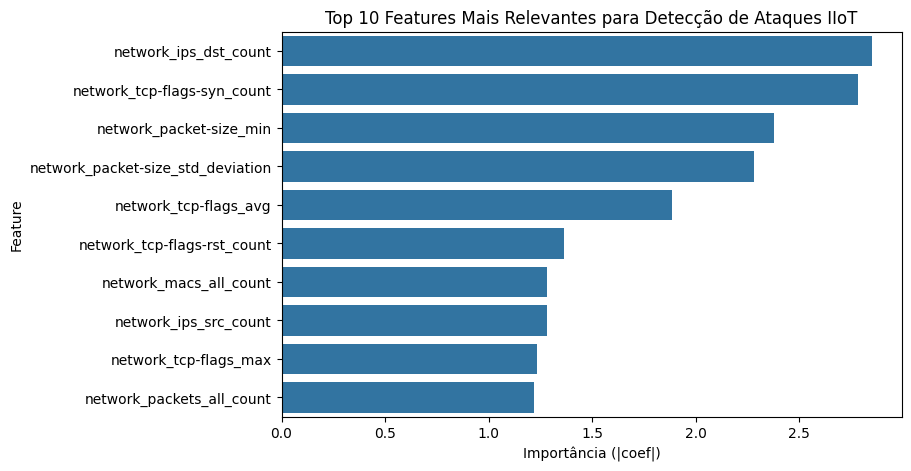

In [32]:

plt.figure(figsize=(8,5))

sns.barplot(
    x="Abs_Importance",
    y="Feature",
    data=feat_imp.head(10)
)

plt.title("Top 10 Features Mais Relevantes para Detecção de Ataques IIoT")
plt.xlabel("Importância (|coef|)")
plt.ylabel("Feature")

plt.show()